# **Data Cleaning**

## Objectives

* Evaluate the missing data
* Clean the data
* Save the cleaned data

## Inputs

* inputs/datasets/raw/house-price-20211124T154130Z-001/house-price/house_prices_records.csv

## Outputs

* Generated cleaned train and test data sets, both saved under outputs/datasets/cleaned 

## Additional Comments

* Data cleaning pipeline 
* Keep only key variables


---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [2]:
import os
current_dir = os.getcwd()
current_dir

'/workspace/PP5-ML/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [3]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [4]:
current_dir = os.getcwd()
current_dir

'/workspace/PP5-ML'

# Section 1 - Load Collected Data

Using the data that we loaded in the Variable_importance stage

In [5]:
import pandas as pd
df_raw_path = "outputs/datasets/collection/housing_prices.csv"
df = pd.read_csv(df_raw_path)
df.head(3)

,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtExposure,BsmtFinSF1,BsmtFinType1,BsmtUnfSF,EnclosedPorch,GarageArea,GarageFinish,...,LotFrontage,MasVnrArea,OpenPorchSF,OverallCond,OverallQual,TotalBsmtSF,WoodDeckSF,YearBuilt,YearRemodAdd,SalePrice
0,856,854.0,3.0,No,706,GLQ,150,0.0,548,RFn,...,65.0,196.0,61,5,7,856,0.0,2003,2003,208500
1,1262,0.0,3.0,Gd,978,ALQ,284,NaN,460,RFn,...,80.0,0.0,0,8,6,1262,NaN,1976,1976,181500
2,920,866.0,3.0,Mn,486,GLQ,434,0.0,608,RFn,...,68.0,162.0,42,5,7,920,NaN,2001,2002,223500


In [6]:
df['SalePrice'].isnull()

0       False
1       False
2       False
3       False
4       False
        ...  
1455    False
1456    False
1457    False
1458    False
1459    False
Name: SalePrice, Length: 1460, dtype: bool

In [7]:
df['SalePrice'].describe().round(2)

count      1460.0
mean     180921.2
std       79442.5
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0
Name: SalePrice, dtype: float64

In [8]:
# Find the minimum value in the SalePrice column 
min_sale_price = df['SalePrice'].min() 
# Find the maximum value in the SalePrice column 
max_sale_price = df['SalePrice'].max() 

print(f"The lowest sale price is: {min_sale_price}") 
print(f"The highest sale price is: {max_sale_price}")

The lowest sale price is: 34900
The highest sale price is: 755000


## Data Exploration

Correlation and PPS Analysis

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ppscore as pps


def heatmap_corr(df, threshold, figsize=(20, 12), font_annot=8):
    if len(df.columns) > 1:
        mask = np.zeros_like(df, dtype=bool)
        mask[np.triu_indices_from(mask)] = True
        mask[abs(df) < threshold] = True

        fig, axes = plt.subplots(figsize=figsize)
        sns.heatmap(df, annot=True, xticklabels=True, yticklabels=True,
                    mask=mask, cmap='viridis', annot_kws={"size": font_annot}, ax=axes,
                    linewidth=0.5
                    )
        axes.set_yticklabels(df.columns, rotation=0)
        plt.ylim(len(df.columns), 0)
        plt.show()


def heatmap_pps(df, threshold, figsize=(20, 12), font_annot=8):
    if len(df.columns) > 1:
        mask = np.zeros_like(df, dtype=bool)
        mask[abs(df) < threshold] = True
        fig, ax = plt.subplots(figsize=figsize)
        ax = sns.heatmap(df, annot=True, xticklabels=True, yticklabels=True,
                         mask=mask, cmap='rocket_r', annot_kws={"size": font_annot},
                         linewidth=0.05, linecolor='grey')
        plt.ylim(len(df.columns), 0)
        plt.show()


def CalculateCorrAndPPS(df):
    df_corr_spearman = df.corr(method="spearman", numeric_only=True)
    df_corr_pearson = df.corr(method="pearson", numeric_only=True)

    pps_matrix_raw = pps.matrix(df)
    pps_matrix = pps_matrix_raw.filter(['x', 'y', 'ppscore']).pivot(columns='x', index='y', values='ppscore')

    pps_score_stats = pps_matrix_raw.query("ppscore < 1").filter(['ppscore']).describe().T
    print("PPS threshold - check PPS score IQR to decide threshold for heatmap \n")
    print(pps_score_stats.round(3))

    return df_corr_pearson, df_corr_spearman, pps_matrix


def DisplayCorrAndPPS(df_corr_pearson, df_corr_spearman, pps_matrix, CorrThreshold, PPS_Threshold,
                      figsize=(20, 12), font_annot=8):

    print("\n")
    print("*** Heatmap: Spearman Correlation ***")
    print("Evaluating the monotonic relationship \n")
    heatmap_corr(df=df_corr_spearman, threshold=CorrThreshold, figsize=figsize, font_annot=font_annot)

    print("\n")
    print("*** Heatmap: Pearson Correlation ***")
    print("Evaluating the linear relationship of continuous variables \n")
    heatmap_corr(df=df_corr_pearson, threshold=CorrThreshold, figsize=figsize, font_annot=font_annot)

    print("\n")
    print("*** Heatmap: Power Predictive Score (PPS) ***")
    print(f"PPS detects linear or non-linear relationships between two columns.\n"
          f"The score ranges from 0 (no predictive power) to 1 (perfect predictive power) \n")
    heatmap_pps(df=pps_matrix, threshold=PPS_Threshold, figsize=figsize, font_annot=font_annot)


In [10]:
df_corr_pearson, df_corr_spearman, pps_matrix = CalculateCorrAndPPS(df)

/workspace/.pip-modules/lib/python3.12/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=4.
  warnings.warn(
/workspace/.pip-modules/lib/python3.12/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=4.
  warnings.warn(
/workspace/.pip-modules/lib/python3.12/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=4.
  warnings.warn(
/workspace/.pip-modules/lib/python3.12/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=4.
  warnings.warn(
/workspace/.pip-modules/lib/python3.12/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=

PPS threshold - check PPS score IQR to decide threshold for heatmap 

         count   mean    std  min  25%  50%    75%    max
ppscore  552.0  0.055  0.104  0.0  0.0  0.0  0.066  0.702


Resulted in the following: 
* Count: 552.0
* Mean: 0.055
* std: 0.104
* min: 0.0
* 25%: 0.0
* 50%: 0.0
* 75%: 0.702

Displaying Heatmaps again



*** Heatmap: Spearman Correlation ***
Evaluating the monotonic relationship 



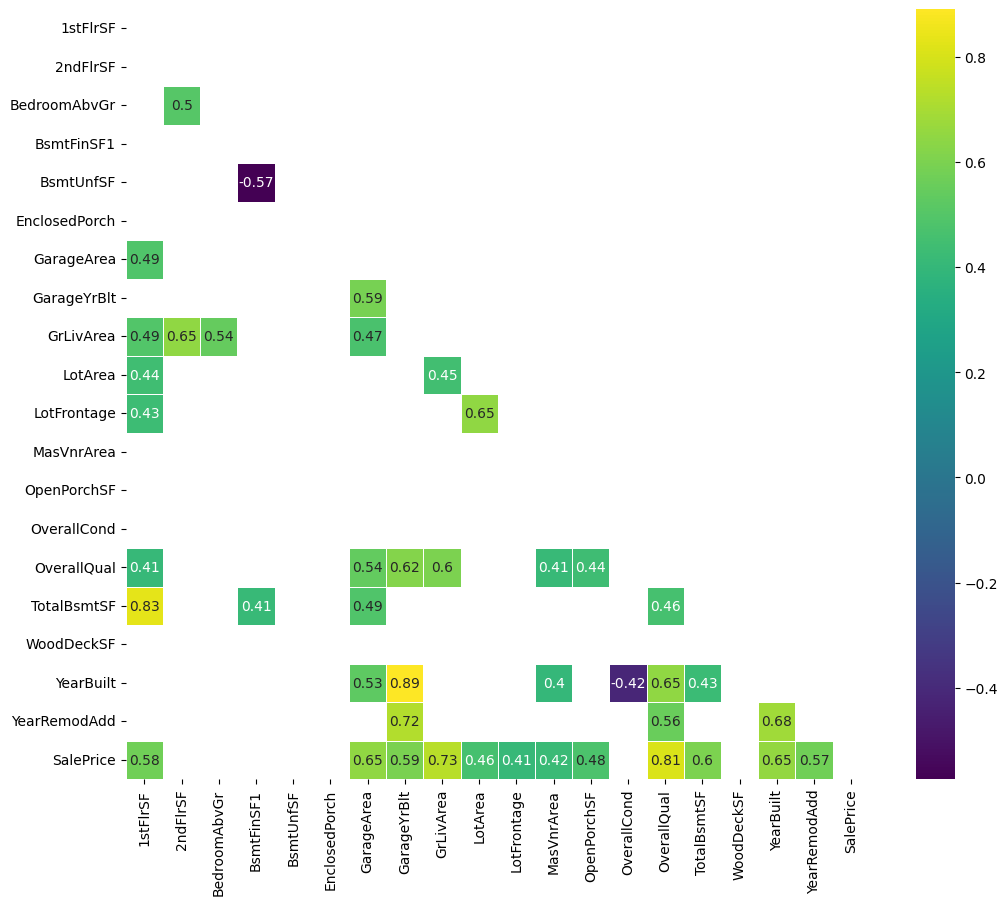



*** Heatmap: Pearson Correlation ***
Evaluating the linear relationship of continuous variables 



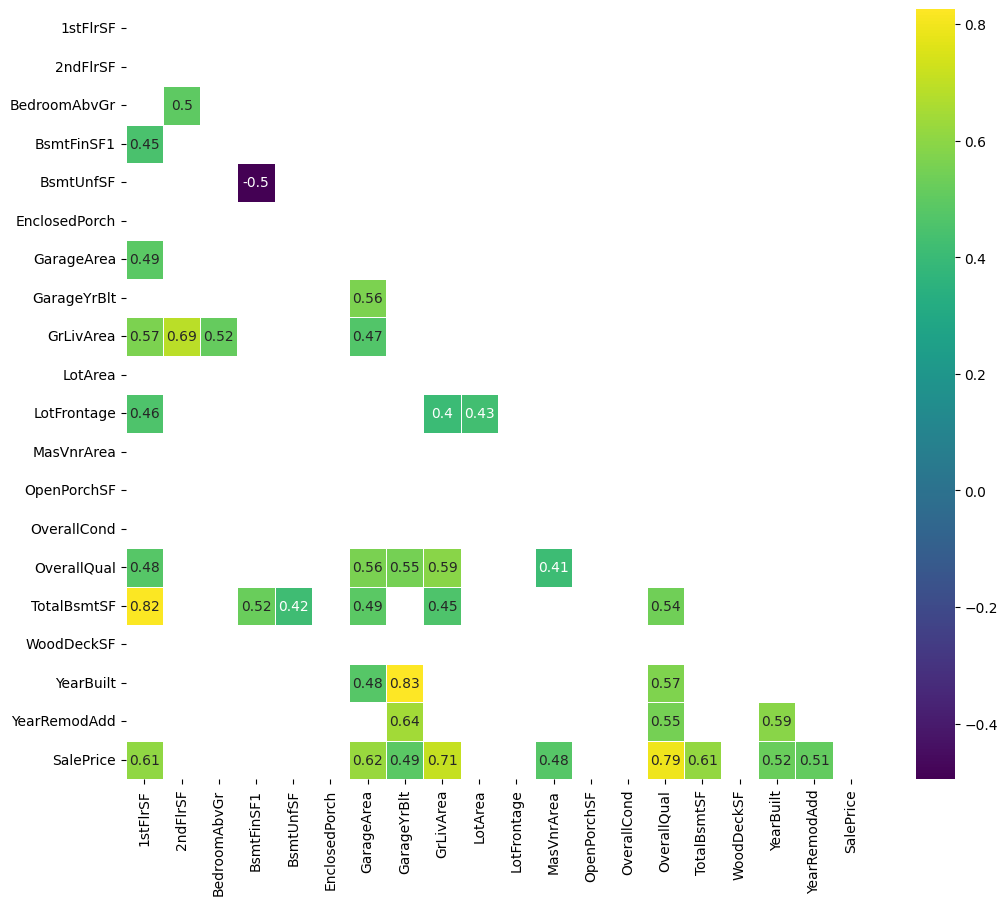



*** Heatmap: Power Predictive Score (PPS) ***
PPS detects linear or non-linear relationships between two columns.
The score ranges from 0 (no predictive power) to 1 (perfect predictive power) 



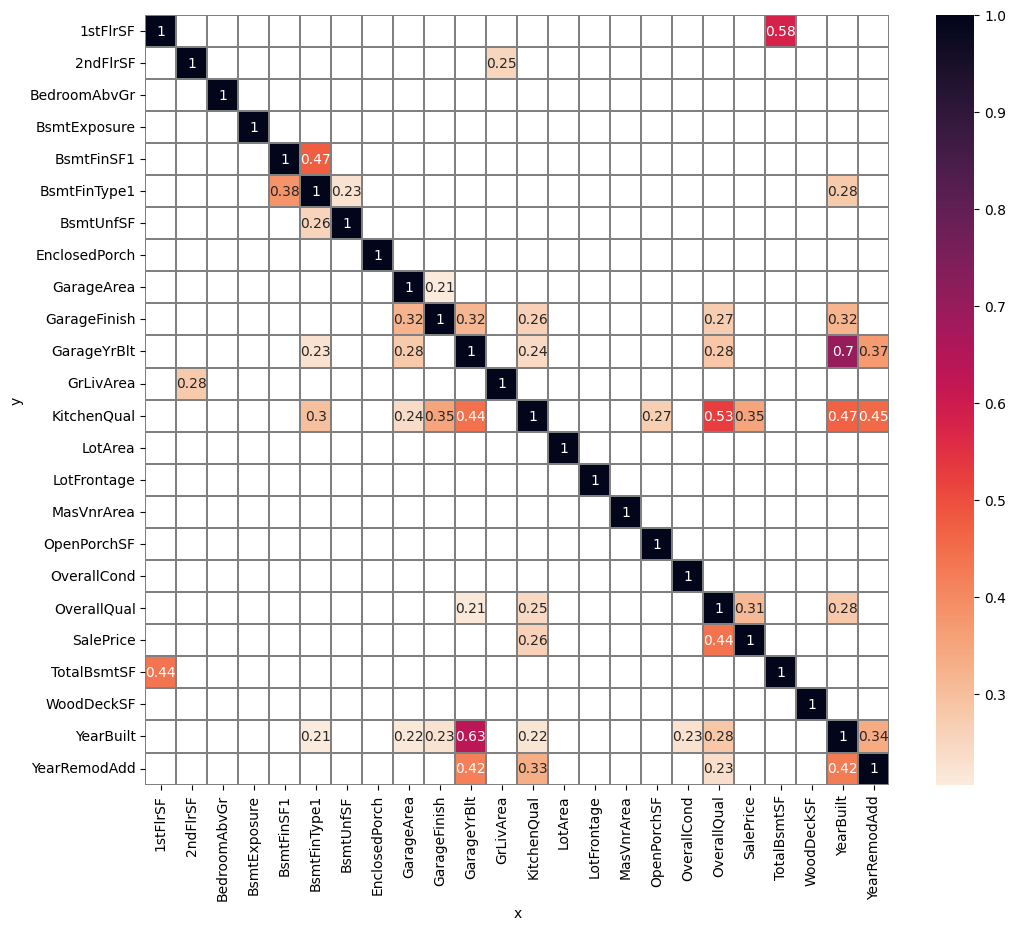

In [11]:
DisplayCorrAndPPS(df_corr_pearson = df_corr_pearson,
                  df_corr_spearman = df_corr_spearman, 
                  pps_matrix = pps_matrix,
                  CorrThreshold = 0.4, PPS_Threshold =0.2,
                  figsize=(12,10), font_annot=10)

------------------

## Assessing the missing data

In [12]:
def EvaluateMissingData(df):
    missing_data_absolute = df.isnull().sum()
    missing_data_percentage = round(missing_data_absolute/len(df)*100, 2)
    df_missing_data = (pd.DataFrame(
                            data={"RowsWithMissingData": missing_data_absolute,
                                   "PercentageOfDataset": missing_data_percentage,
                                   "DataType": df.dtypes}
                                    )
                          .sort_values(by=['PercentageOfDataset'], ascending=False)
                          .query("PercentageOfDataset > 0")
                          )

    return df_missing_data

In [13]:
EvaluateMissingData(df)

,RowsWithMissingData,PercentageOfDataset,DataType
EnclosedPorch,1324,90.68,float64
WoodDeckSF,1305,89.38,float64
LotFrontage,259,17.74,float64
GarageFinish,162,11.10,object
BsmtFinType1,114,7.81,object
BedroomAbvGr,99,6.78,float64
2ndFlrSF,86,5.89,float64
GarageYrBlt,81,5.55,float64
MasVnrArea,8,0.55,float64


We know that we dont need the EnclosedPorch, WoodDeckSF, LotFrontage, GarageFinish, BsmtFinType1 based on the previous notebook where we studied the variables correlations

In [14]:
df.head(2)

,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtExposure,BsmtFinSF1,BsmtFinType1,BsmtUnfSF,EnclosedPorch,GarageArea,GarageFinish,...,LotFrontage,MasVnrArea,OpenPorchSF,OverallCond,OverallQual,TotalBsmtSF,WoodDeckSF,YearBuilt,YearRemodAdd,SalePrice
0,856,854.0,3.0,No,706,GLQ,150,0.0,548,RFn,...,65.0,196.0,61,5,7,856,0.0,2003,2003,208500
1,1262,0.0,3.0,Gd,978,ALQ,284,NaN,460,RFn,...,80.0,0.0,0,8,6,1262,NaN,1976,1976,181500


In [15]:
Cleaned_data = df.drop(columns=['EnclosedPorch', 'WoodDeckSF', 'LotFrontage', 'GarageFinish', 'BsmtFinType1', 'BedroomAbvGr', 'GarageYrBlt', 'MasVnrArea', 'BsmtExposure', 'YearRemodAdd', 'OpenPorchSF', 'BsmtUnfSF', 'KitchenQual'])

We can aslo use a simple Imputer on the rest of the missing data

In [16]:
from sklearn.impute import SimpleImputer

fillable_columns = ['2ndFlrSF']

imputer_num = SimpleImputer(strategy='mean')
Cleaned_data[fillable_columns] = imputer_num.fit_transform(Cleaned_data[fillable_columns])



In [17]:
Cleaned_data.describe().round(2)

,1stFlrSF,2ndFlrSF,BsmtFinSF1,GarageArea,GrLivArea,LotArea,OverallCond,OverallQual,TotalBsmtSF,YearBuilt,SalePrice
count,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.0
mean,1162.63,348.52,443.64,472.98,1515.46,10516.83,5.58,6.10,1057.43,1971.27,180921.2
std,386.59,425.73,456.10,213.80,525.48,9981.26,1.11,1.38,438.71,30.20,79442.5
min,334.00,0.00,0.00,0.00,334.00,1300.00,1.00,1.00,0.00,1872.00,34900.0
25%,882.00,0.00,0.00,334.50,1129.50,7553.50,5.00,5.00,795.75,1954.00,129975.0
50%,1087.00,0.00,383.50,480.00,1464.00,9478.50,5.00,6.00,991.50,1973.00,163000.0
75%,1391.25,714.50,712.25,576.00,1776.75,11601.50,6.00,7.00,1298.25,2000.00,214000.0
max,4692.00,2065.00,5644.00,1418.00,5642.00,215245.00,9.00,10.00,6110.00,2010.00,755000.0


In [18]:
Cleaned_data.head()

,1stFlrSF,2ndFlrSF,BsmtFinSF1,GarageArea,GrLivArea,LotArea,OverallCond,OverallQual,TotalBsmtSF,YearBuilt,SalePrice
0,856,854.000000,706,548,1710,8450,5,7,856,2003,208500
1,1262,0.000000,978,460,1262,9600,8,6,1262,1976,181500
2,920,866.000000,486,608,1786,11250,5,7,920,2001,223500
3,961,348.524017,216,642,1717,9550,5,7,756,1915,140000
4,1145,348.524017,655,836,2198,14260,5,8,1145,2000,250000


## Ordinal Encoder

In [19]:
Cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   1stFlrSF     1460 non-null   int64  
 1   2ndFlrSF     1460 non-null   float64
 2   BsmtFinSF1   1460 non-null   int64  
 3   GarageArea   1460 non-null   int64  
 4   GrLivArea    1460 non-null   int64  
 5   LotArea      1460 non-null   int64  
 6   OverallCond  1460 non-null   int64  
 7   OverallQual  1460 non-null   int64  
 8   TotalBsmtSF  1460 non-null   int64  
 9   YearBuilt    1460 non-null   int64  
 10  SalePrice    1460 non-null   int64  
dtypes: float64(1), int64(10)
memory usage: 125.6 KB


## Split into train and test datasets

In [20]:
from sklearn.model_selection import train_test_split
TrainSet, TestSet, _, __ = train_test_split(
                                        Cleaned_data,
                                        Cleaned_data['SalePrice'],
                                        test_size=0.2,
                                        random_state=0)

print(f"TrainSet shape: {TrainSet.shape} \nTestSet shape: {TestSet.shape}")

TrainSet shape: (1168, 11) 
TestSet shape: (292, 11)


---

In [21]:
TrainSet.head()

,1stFlrSF,2ndFlrSF,BsmtFinSF1,GarageArea,GrLivArea,LotArea,OverallCond,OverallQual,TotalBsmtSF,YearBuilt,SalePrice
618,1828,0.0,48,774,1828,11694,5,9,1822,2007,314813
870,894,0.0,0,308,894,6600,5,5,894,1962,109500
92,964,0.0,713,432,964,13360,7,5,876,1921,163500
817,1689,0.0,1218,857,1689,13265,5,8,1568,2002,271000
302,1541,0.0,0,843,1541,13704,5,7,1541,2001,205000


In [22]:
TestSet.head()

,1stFlrSF,2ndFlrSF,BsmtFinSF1,GarageArea,GrLivArea,LotArea,OverallCond,OverallQual,TotalBsmtSF,YearBuilt,SalePrice
529,2515,0.000000,1219,484,2515,32668,3,6,2035,1957,200624
491,958,620.000000,403,240,1578,9490,7,6,806,1941,133000
459,979,224.000000,185,352,1203,7015,4,5,709,1950,110000
279,1156,866.000000,392,505,2022,10005,5,7,1160,1977,192000
655,525,348.524017,0,264,1092,1680,5,6,525,1971,88000


# Section 2 - Pushing cleaned data to repo

Training set

In [23]:
TrainSet.to_csv("outputs/datasets/cleaned/TrainSetCleaned.csv", index=False)

Test SEt

In [24]:
TestSet.to_csv("outputs/datasets/cleaned/TestSetCleaned.csv", index=False)

In [25]:
Cleaned_data.to_csv("outputs/datasets/cleaned/CleanedDataset.csv", index=False)

---

Next Steps
* now that we have cleaned the data and split it into training and testing data 
* We will now make a new notebook that will take these datasets to 

---